# LAB 6: NHẬN DIỆN ẢNH (IMAGE DETECTION)

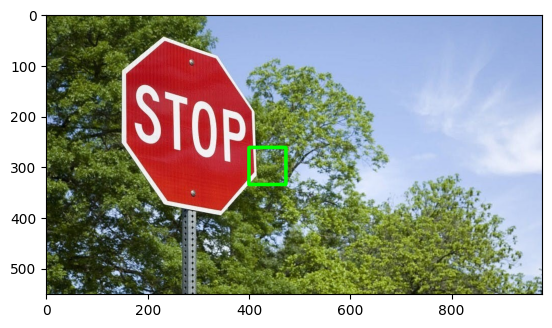

In [2]:
# code tham khảo
import cv2
import matplotlib.pyplot as vuong
img = cv2.imread("stop.jpg")
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# dots that would look like STOP signs
stop_data = cv2.CascadeClassifier('haarcascade_frontalface_default.xml') #('/content/haarcascade_frontalcatface.xml')
found = stop_data.detectMultiScale(img_gray,minSize =(20, 20))
amount_found = len(found)

if amount_found != 0:
    for (x, y, width, height) in found:
        cv2.rectangle(img_rgb, (x, y),
                      (x + height, y + width),
                      (0, 255, 0), 5)
vuong.imshow(img_rgb)


In [4]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Tải các file XML (cần tải về và đặt trong cùng folder)
# Download từ: https://github.com/kipr/opencv/tree/master/data/haarcascades
face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')
smile_cascade = cv2.CascadeClassifier('haarcascade_smile.xml')
nose_cascade = cv2.CascadeClassifier('haarcascade_mcs_nose.xml')
mouth_cascade = cv2.CascadeClassifier('haarcascade_mcs_mouth.xml')

print("Đã tải xong các cascade classifier")

Đã tải xong các cascade classifier


Tìm thấy 5 khuôn mặt


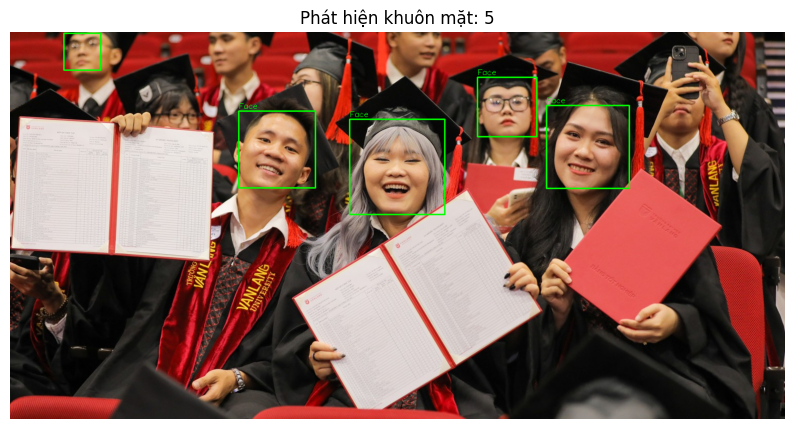

In [5]:
# Đọc ảnh
img = cv2.imread('people.jpg')  # hoặc ảnh tập thể, kỷ yếu
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Phát hiện khuôn mặt
faces = face_cascade.detectMultiScale(img_gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

print(f"Tìm thấy {len(faces)} khuôn mặt")

# Vẽ khung quanh khuôn mặt
for (x, y, w, h) in faces:
    cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(img_rgb, 'Face', (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)

plt.figure(figsize=(10,8))
plt.imshow(img_rgb)
plt.title(f'Phát hiện khuôn mặt: {len(faces)}')
plt.axis('off')
plt.show()

Khuôn mặt tại (105,4): 2 mắt, 1 mũi, 1 miệng, 0 nụ cười
Khuôn mặt tại (914,90): 2 mắt, 1 mũi, 1 miệng, 1 nụ cười
Khuôn mặt tại (664,172): 0 mắt, 1 mũi, 1 miệng, 1 nụ cười
Khuôn mặt tại (1049,145): 2 mắt, 1 mũi, 1 miệng, 1 nụ cười
Khuôn mặt tại (447,156): 2 mắt, 1 mũi, 1 miệng, 1 nụ cười


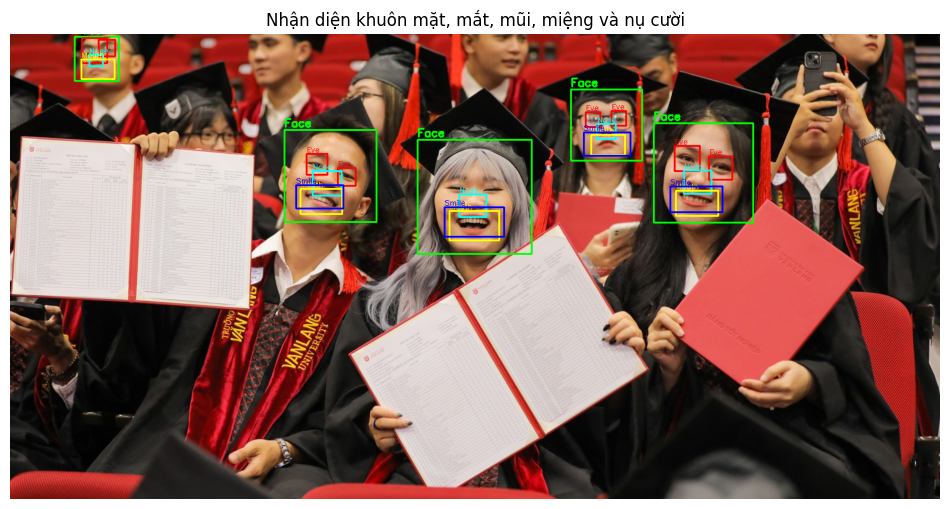

In [11]:
# Copy ảnh gốc để vẽ
img_result = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Duyệt từng khuôn mặt đã phát hiện
for (x, y, w, h) in faces:
    # Vẽ khung khuôn mặt
    cv2.rectangle(img_result, (x, y), (x + w, y + h), (0, 255, 0), 2)
    cv2.putText(img_result, 'Face', (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    
    # Vùng quan tâm (ROI) trên khuôn mặt
    roi_gray = img_gray[y:y+h, x:x+w]
    roi_color = img_result[y:y+h, x:x+w]
    
    # 1. Phát hiện mắt - CHỈ LẤY 2 MẮT
    eyes = eye_cascade.detectMultiScale(roi_gray, scaleFactor=1.05, minNeighbors=3, minSize=(10, 10))
    
    # Lọc mắt: chỉ lấy những mắt ở nửa trên khuôn mặt
    eyes_filtered = []
    for (ex, ey, ew, eh) in eyes:
        if ey < h * 0.5:
            eyes_filtered.append((ex, ey, ew, eh))
    
    # Chỉ lấy 2 mắt lớn nhất
    if len(eyes_filtered) > 2:
        eyes_filtered = sorted(eyes_filtered, key=lambda e: e[2]*e[3], reverse=True)[:2]
    
    # Vẽ mắt
    for (ex, ey, ew, eh) in eyes_filtered:
        cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (255, 0, 0), 2)
        cv2.putText(roi_color, 'Eye', (ex, ey-3), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)
    
    # 2. Phát hiện mũi - CHỈ LẤY 1 MŨI
    noses = nose_cascade.detectMultiScale(roi_gray, scaleFactor=1.05, minNeighbors=3, minSize=(15, 15))
    
    # Lọc mũi: nên ở giữa khuôn mặt
    noses_filtered = []
    for (nx, ny, nw, nh) in noses:
        if h*0.3 < ny < h*0.7:
            noses_filtered.append((nx, ny, nw, nh))
    
    # Chỉ lấy 1 mũi tốt nhất
    if len(noses_filtered) > 1:
        noses_filtered = sorted(noses_filtered, key=lambda n: n[2]*n[3], reverse=True)[:1]
    
    for (nx, ny, nw, nh) in noses_filtered:
        cv2.rectangle(roi_color, (nx, ny), (nx + nw, ny + nh), (0, 255, 255), 2)
        cv2.putText(roi_color, 'Nose', (nx, ny-3), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 255), 1)
    
    # 3. Phát hiện miệng - CHỈ LẤY 1 MIỆNG
    mouths = mouth_cascade.detectMultiScale(roi_gray, scaleFactor=1.05, minNeighbors=3, minSize=(20, 20))
    
    # Lọc miệng: nên ở nửa dưới khuôn mặt
    mouths_filtered = []
    for (mx, my, mw, mh) in mouths:
        if my > h * 0.5:
            mouths_filtered.append((mx, my, mw, mh))
    
    # Chỉ lấy 1 miệng tốt nhất
    if len(mouths_filtered) > 1:
        mouths_filtered = sorted(mouths_filtered, key=lambda m: m[2]*m[3], reverse=True)[:1]
    
    for (mx, my, mw, mh) in mouths_filtered:
        cv2.rectangle(roi_color, (mx, my), (mx + mw, my + mh), (255, 255, 0), 2)
        cv2.putText(roi_color, 'Mouth', (mx, my-3), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 0), 1)
    
    # 4. Phát hiện nụ cười - CHỈ LẤY 1 NỤ CƯỜI
    smiles = smile_cascade.detectMultiScale(roi_gray, scaleFactor=1.2, minNeighbors=10, minSize=(15, 15))
    
    # Lọc nụ cười: nên ở vùng miệng
    smiles_filtered = []
    for (sx, sy, sw, sh) in smiles:
        # Nụ cười nên ở nửa dưới khuôn mặt
        if sy > h * 0.5:
            smiles_filtered.append((sx, sy, sw, sh))
    
    # Chỉ lấy 1 nụ cười tốt nhất
    if len(smiles_filtered) > 1:
        smiles_filtered = sorted(smiles_filtered, key=lambda s: s[2]*s[3], reverse=True)[:1]
    
    for (sx, sy, sw, sh) in smiles_filtered:
        cv2.rectangle(roi_color, (sx, sy), (sx + sw, sy + sh), (0, 0, 255), 2)
        cv2.putText(roi_color, 'Smile', (sx, sy-3), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)
    
    # In số lượng phát hiện được
    print(f"Khuôn mặt tại ({x},{y}): {len(eyes_filtered)} mắt, {len(noses_filtered)} mũi, {len(mouths_filtered)} miệng, {len(smiles_filtered)} nụ cười")

plt.figure(figsize=(12,8))
plt.imshow(img_result)
plt.title('Nhận diện khuôn mặt, mắt, mũi, miệng và nụ cười')
plt.axis('off')
plt.show()

Khuôn mặt tại (105,4): 3 mắt, 0 nụ cười, 0 mũi, 1 miệng
Khuôn mặt tại (914,90): 2 mắt, 0 nụ cười, 1 mũi, 4 miệng
Khuôn mặt tại (664,172): 1 mắt, 1 nụ cười, 2 mũi, 3 miệng
Khuôn mặt tại (1049,145): 3 mắt, 0 nụ cười, 1 mũi, 3 miệng
Khuôn mặt tại (447,156): 2 mắt, 0 nụ cười, 2 mũi, 2 miệng


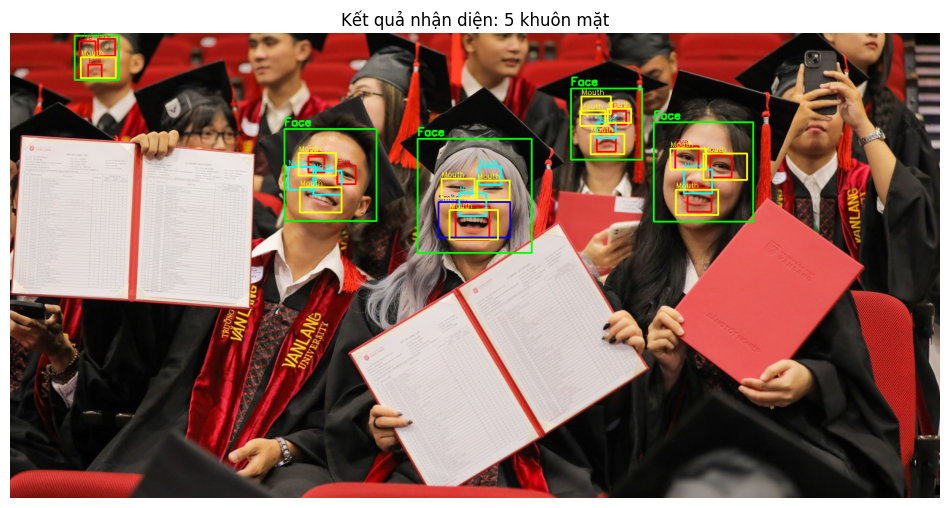

In [13]:
def detect_facial_features(img_path):
    """
    Nhận diện đầy đủ các bộ phận trên khuôn mặt
    """
    # Đọc ảnh
    img = cv2.imread(img_path)
    if img is None:
        print(f"Không tìm thấy ảnh: {img_path}")
        return None, 0
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Phát hiện khuôn mặt
    faces = face_cascade.detectMultiScale(img_gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
    
    if len(faces) == 0:
        print("Không tìm thấy khuôn mặt nào!")
        return img_rgb, 0
    
    for (x, y, w, h) in faces:
        # Vẽ khung khuôn mặt
        cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(img_rgb, 'Face', (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        
        # ROI trên khuôn mặt
        roi_gray = img_gray[y:y+h, x:x+w]
        roi_color = img_rgb[y:y+h, x:x+w]
        
        # 1. Mắt
        eyes = eye_cascade.detectMultiScale(roi_gray, 1.1, 5, minSize=(15, 15))
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (255, 0, 0), 2)
            cv2.putText(roi_color, 'Eye', (ex, ey-3), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 0, 0), 1)
        
        # 2. Nụ cười
        smiles = smile_cascade.detectMultiScale(roi_gray, 1.8, 20, minSize=(20, 20))
        for (sx, sy, sw, sh) in smiles:
            cv2.rectangle(roi_color, (sx, sy), (sx + sw, sy + sh), (0, 0, 255), 2)
            cv2.putText(roi_color, 'Smile', (sx, sy-3), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)
        
        # 3. Mũi
        noses = nose_cascade.detectMultiScale(roi_gray, 1.1, 5, minSize=(20, 20))
        for (nx, ny, nw, nh) in noses:
            cv2.rectangle(roi_color, (nx, ny), (nx + nw, ny + nh), (0, 255, 255), 2)
            cv2.putText(roi_color, 'Nose', (nx, ny-3), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 255), 1)
        
        # 4. Miệng
        mouths = mouth_cascade.detectMultiScale(roi_gray, 1.1, 5, minSize=(20, 20))
        for (mx, my, mw, mh) in mouths:
            cv2.rectangle(roi_color, (mx, my), (mx + mw, my + mh), (255, 255, 0), 2)
            cv2.putText(roi_color, 'Mouth', (mx, my-3), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 0), 1)
        
        # In kết quả
        print(f"Khuôn mặt tại ({x},{y}): {len(eyes)} mắt, {len(smiles)} nụ cười, {len(noses)} mũi, {len(mouths)} miệng")
    
    return img_rgb, len(faces)

# Chạy thử
result_img, num_faces = detect_facial_features('people.jpg')
if result_img is not None:
    plt.figure(figsize=(12,8))
    plt.imshow(result_img)
    plt.title(f'Kết quả nhận diện: {num_faces} khuôn mặt')
    plt.axis('off')
    plt.show()

Tổng số người trong ảnh: 5
Người #1: 3 mắt, 0 nụ cười, 0 mũi, 1 miệng
Người #2: 2 mắt, 0 nụ cười, 1 mũi, 4 miệng
Người #3: 3 mắt, 0 nụ cười, 1 mũi, 3 miệng
Người #4: 1 mắt, 1 nụ cười, 2 mũi, 3 miệng
Người #5: 2 mắt, 0 nụ cười, 2 mũi, 2 miệng


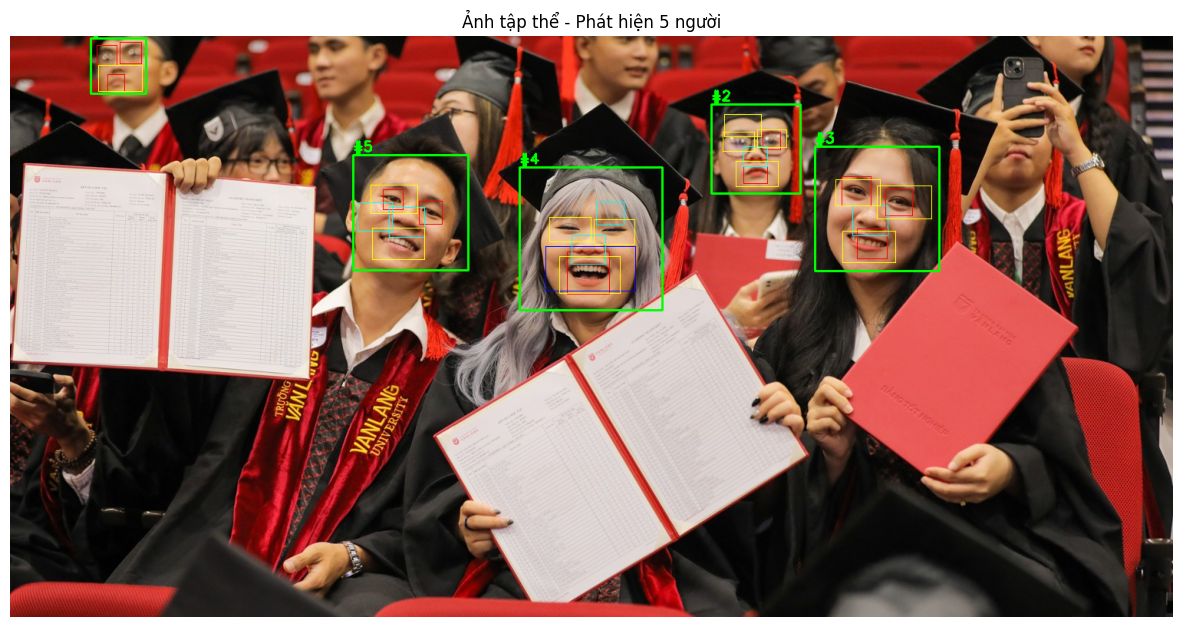

In [14]:
# Đọc ảnh tập thể (thay tên file phù hợp)
group_img = cv2.imread('people.jpg')  # Thay bằng ảnh kỷ yếu của bạn

if group_img is None:
    print("Không tìm thấy ảnh tập thể, vui lòng kiểm tra tên file!")
else:
    group_rgb = cv2.cvtColor(group_img, cv2.COLOR_BGR2RGB)
    group_gray = cv2.cvtColor(group_img, cv2.COLOR_BGR2GRAY)
    
    # Phát hiện tất cả khuôn mặt
    faces = face_cascade.detectMultiScale(group_gray, scaleFactor=1.1, minNeighbors=5, minSize=(50, 50))
    
    print(f"Tổng số người trong ảnh: {len(faces)}")
    
    # Vẽ khung và đánh số thứ tự
    for i, (x, y, w, h) in enumerate(faces):
        cv2.rectangle(group_rgb, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(group_rgb, f'#{i+1}', (x, y-5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        
        # ROI cho từng khuôn mặt
        roi_gray = group_gray[y:y+h, x:x+w]
        roi_color = group_rgb[y:y+h, x:x+w]
        
        # Phát hiện các bộ phận trên từng người
        eyes = eye_cascade.detectMultiScale(roi_gray, 1.1, 5, minSize=(15, 15))
        smiles = smile_cascade.detectMultiScale(roi_gray, 1.8, 20, minSize=(20, 20))
        noses = nose_cascade.detectMultiScale(roi_gray, 1.1, 5, minSize=(20, 20))
        mouths = mouth_cascade.detectMultiScale(roi_gray, 1.1, 5, minSize=(20, 20))
        
        # Vẽ mắt
        for (ex, ey, ew, eh) in eyes:
            cv2.rectangle(roi_color, (ex, ey), (ex + ew, ey + eh), (255, 0, 0), 1)
        
        # Vẽ nụ cười
        for (sx, sy, sw, sh) in smiles:
            cv2.rectangle(roi_color, (sx, sy), (sx + sw, sy + sh), (0, 0, 255), 1)
        
        # Vẽ mũi
        for (nx, ny, nw, nh) in noses:
            cv2.rectangle(roi_color, (nx, ny), (nx + nw, ny + nh), (0, 255, 255), 1)
        
        # Vẽ miệng
        for (mx, my, mw, mh) in mouths:
            cv2.rectangle(roi_color, (mx, my), (mx + mw, my + mh), (255, 255, 0), 1)
        
        print(f"Người #{i+1}: {len(eyes)} mắt, {len(smiles)} nụ cười, {len(noses)} mũi, {len(mouths)} miệng")
    
    plt.figure(figsize=(15,10))
    plt.imshow(group_rgb)
    plt.title(f'Ảnh tập thể - Phát hiện {len(faces)} người')
    plt.axis('off')
    plt.show()